In [1]:
%pip install seaborn
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 7.2 MB/s eta 0:00:02
   ------ --------------------------------- 1.3/8.0 MB 3.9 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.0 MB 4.2 MB/s eta 0:00:02
   ----------------- ---------------------- 3.4/8.0 MB 4.6 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.0 MB 4.7 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.0 MB 4.7 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.0 MB 4.7 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.0 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 4.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
    --------------------------------------- 0.8/36.5 MB 4.7 MB/s eta 0:00:08
   -- ------------------------------------- 2.1/36.5 MB 5.1 MB/s eta 0:00:07
   --- ----------------


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip




Датасет `data.csv` містить дані про студентів та підсумкові семестрові оцінки. 

Цільовою змінною є "GRADE" -- це підсумкова оцінка за семестр (мінімальне значення 0, максимальне 20)

Файл `attributes.csv` містить повні назви ознак.

Датасет `predict.csv` не містить оцінок і призначений для зовнішнього оцінювання. 













In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score


sns.set_style('whitegrid')
%matplotlib inline

## Завдання 1

[2 бали] 

Імпортувати датасет `data.csv` у об'єкт `DataFrame` і провести попередній аналіз даних засобами `pandas`, `matplotlib`, `seaborn`.  

In [3]:
data = pd.read_csv('data.csv')
print("Розмір датасету:", data.shape)
data.head()

Розмір датасету: (944, 32)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,sem,GRADE
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,4,3,4,1,1,3,4,-2.302585,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,no,5,3,3,1,1,3,2,2.208274,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,no,4,3,2,2,3,3,6,2.493205,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,3,2,2,1,1,5,0,2.646175,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,4,3,2,1,2,5,0,2.406945,13


In [4]:
data.info()
print("\nКількість пропусків у кожному стовпці:\n", data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 32 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      944 non-null    object 
 1   sex         944 non-null    object 
 2   age         944 non-null    int64  
 3   address     944 non-null    object 
 4   famsize     944 non-null    object 
 5   Pstatus     944 non-null    object 
 6   Medu        944 non-null    int64  
 7   Fedu        944 non-null    int64  
 8   Mjob        944 non-null    object 
 9   Fjob        944 non-null    object 
 10  reason      944 non-null    object 
 11  guardian    944 non-null    object 
 12  traveltime  944 non-null    int64  
 13  studytime   944 non-null    int64  
 14  failures    944 non-null    int64  
 15  schoolsup   944 non-null    object 
 16  famsup      944 non-null    object 
 17  paid        944 non-null    object 
 18  activities  944 non-null    object 
 19  nursery     944 non-null    o

In [5]:
data.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,sem,GRADE
count,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000
mean,16.688559,2.636653,2.404661,1.507415,1.985169,0.253178,3.940678,3.192797,3.145127,1.475636,2.282839,3.527542,4.385593,2.284653,11.469280
std,1.204638,1.129181,1.098258,0.723744,0.832653,0.645147,0.907538,1.028188,1.137949,0.877091,1.268545,1.434791,6.331564,0.679939,3.794162
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,-2.302585,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,2.208274,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,2.406945,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,2.572612,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,2.949688,20.000000


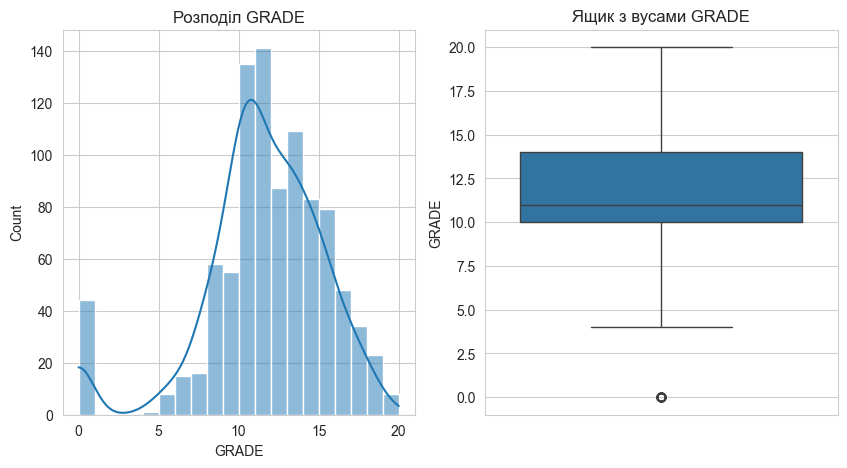

In [6]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(data['GRADE'], bins=20, kde=True)
plt.title('Розподіл GRADE')
plt.subplot(1,2,2)
sns.boxplot(y=data['GRADE'])
plt.title('Ящик з вусами GRADE')
plt.show()

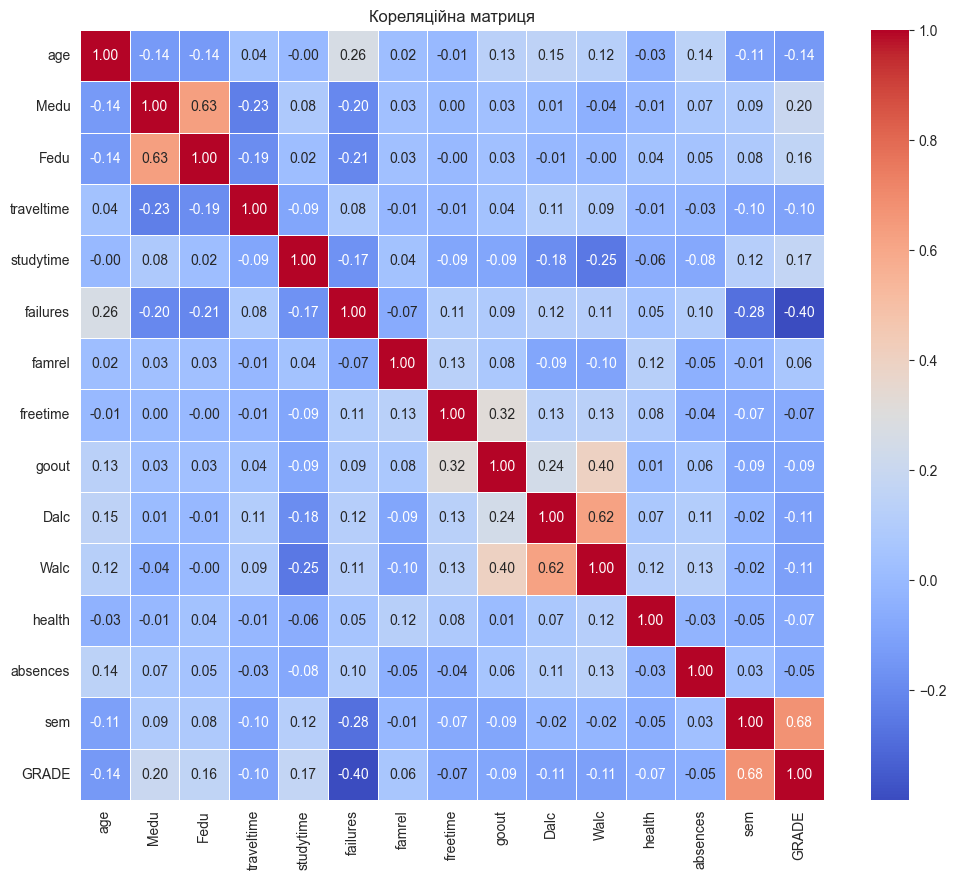

In [7]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('GRADE')
plt.figure(figsize=(12,10))
corr = data[numeric_cols + ['GRADE']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Кореляційна матриця')
plt.show()

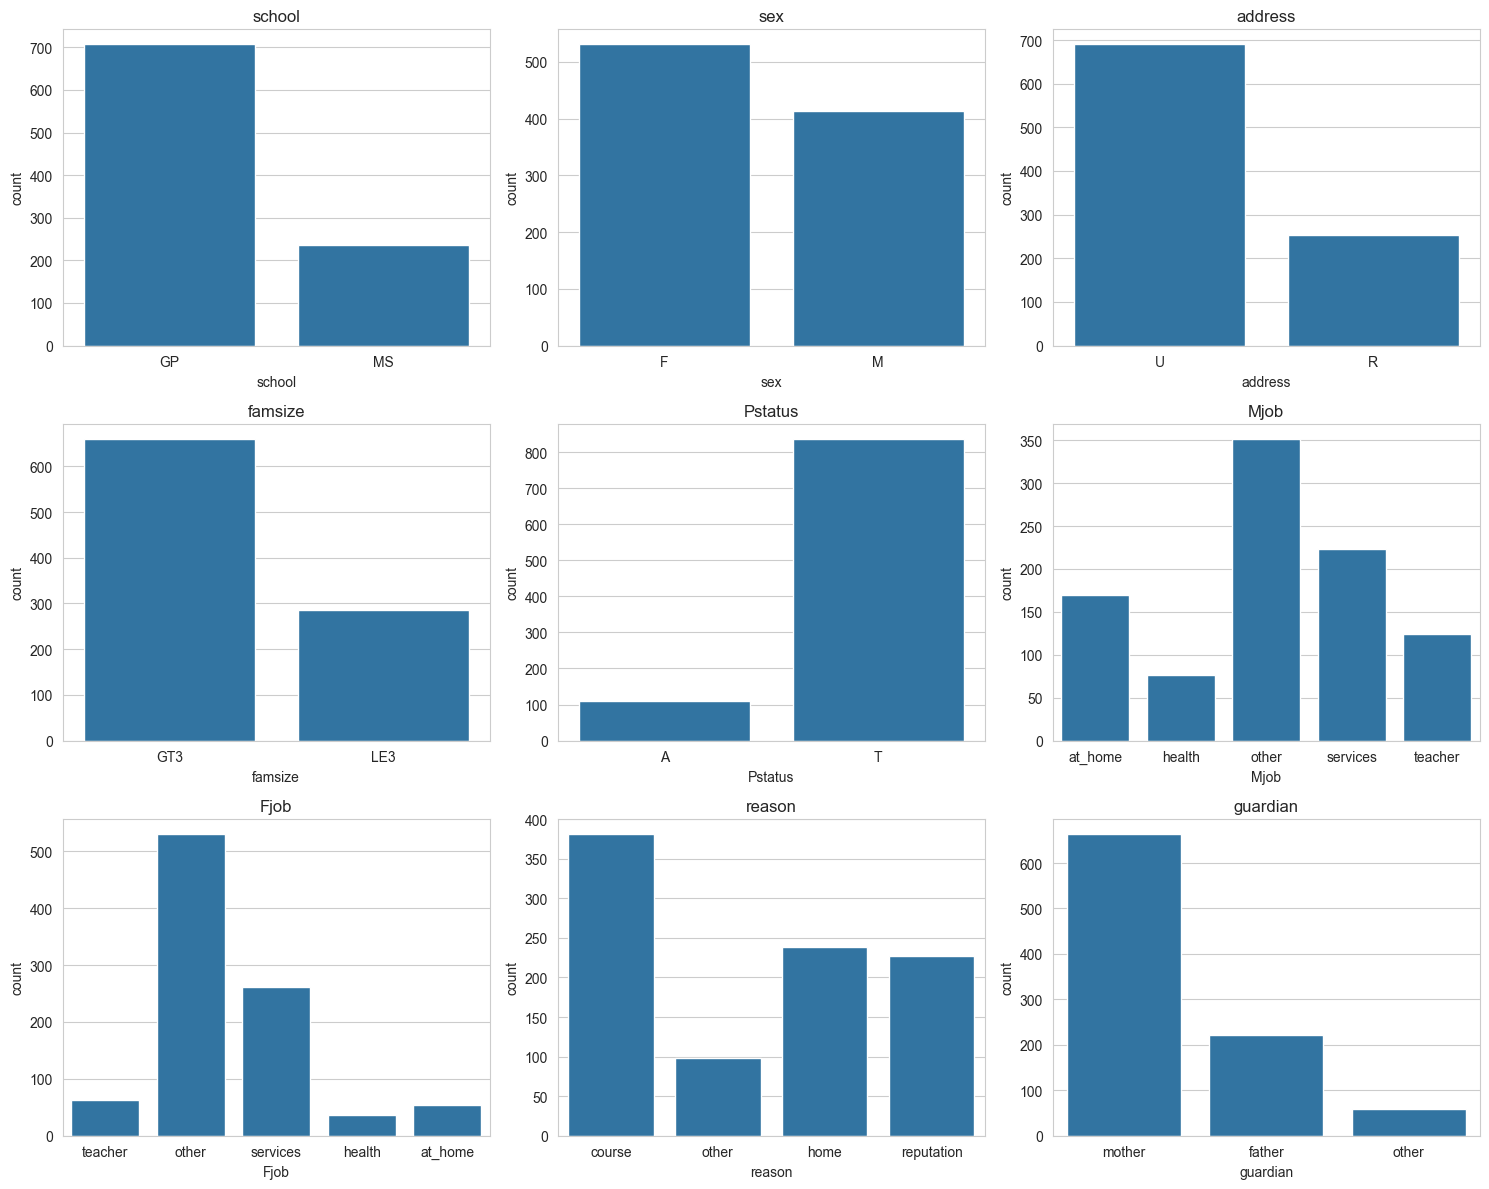

In [8]:
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, col in enumerate(categorical_cols[:9]):
    sns.countplot(data=data, x=col, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(col)
plt.tight_layout()
plt.show()

In [9]:
X = data.drop('GRADE', axis=1)
y = data['GRADE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Розмір навчальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")

Розмір навчальної вибірки: (755, 31)
Розмір тестової вибірки: (189, 31)


## Завдання 2

[2 бали] 

Навчити модель лінійної регресії (`sklearn.linear_model.LinearRegression`) лише за числовими ознаками. 

Розглянути також варіанти з регуляризацією (`Ridge`, `Lasso`). Знайти оптимальні параметри регуляризації (`alpha`) за допомогою процедури крос-валідації.

Для всіх моделей знайти коефіцієнт детермінації на відкладеній вибірці.

Зробити висновки.

In [10]:
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Числові ознаки:", num_features)

X_train_num = X_train[num_features]
X_test_num = X_test[num_features]

scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

Числові ознаки: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'sem']


In [11]:
lr = LinearRegression()
lr.fit(X_train_num_scaled, y_train)
y_pred_lr = lr.predict(X_test_num_scaled)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"LinearRegression R^2 на тесті: {r2_lr:.4f}")

LinearRegression R^2 на тесті: 0.5270


In [12]:
ridge = Ridge()
param_grid_ridge = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_cv = GridSearchCV(ridge, param_grid_ridge, cv=5, scoring='r2')
ridge_cv.fit(X_train_num_scaled, y_train)
print(f"Найкраще alpha для Ridge: {ridge_cv.best_params_['alpha']}")
best_ridge = ridge_cv.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_num_scaled)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"Ridge R^2 на тесті: {r2_ridge:.4f}")

Найкраще alpha для Ridge: 10
Ridge R^2 на тесті: 0.5268


In [13]:
lasso = Lasso(max_iter=10000)
param_grid_lasso = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
lasso_cv = GridSearchCV(lasso, param_grid_lasso, cv=5, scoring='r2')
lasso_cv.fit(X_train_num_scaled, y_train)
print(f"Найкраще alpha для Lasso: {lasso_cv.best_params_['alpha']}")
best_lasso = lasso_cv.best_estimator_
y_pred_lasso = best_lasso.predict(X_test_num_scaled)
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f"Lasso R^2 на тесті: {r2_lasso:.4f}")

Найкраще alpha для Lasso: 0.1
Lasso R^2 на тесті: 0.5228


In [14]:
print("Результати на числових ознаках:")
print(f"LinearRegression R² = {r2_lr:.4f}")
print(f"Ridge (alpha={ridge_cv.best_params_['alpha']}) R² = {r2_ridge:.4f}")
print(f"Lasso (alpha={lasso_cv.best_params_['alpha']}) R² = {r2_lasso:.4f}")
if r2_ridge > r2_lr and r2_ridge > r2_lasso:
    print("Найкраща модель на числових ознаках – Ridge (завдяки регуляризації, яка зменшує переобучення).")
elif r2_lasso > r2_lr:
    print("Найкраща модель на числових ознаках – Lasso (може відбирати ознаки).")
else:
    print("Найкраща модель – звичайна лінійна регресія (без регуляризації).")

Результати на числових ознаках:
LinearRegression R² = 0.5270
Ridge (alpha=10) R² = 0.5268
Lasso (alpha=0.1) R² = 0.5228
Найкраща модель – звичайна лінійна регресія (без регуляризації).


## Завдання 3

[3 балів] 

Навчити модель лінійної регресії з використанням усіх ознак (застосувати one-hot кодування, бінаризацію тощо до нечислових ознак).

* Спробувати `LinearRegression`, `Ridge`, `Lasso`, `SGDRegressor(loss='squared_error')`, експерементуючи з кількістю і складом ознак та  підбором основних гіперпараметрів. 
    * `alpha` для `Ridge` та `Lasso`
    * `penalty`, `alpha`, `learning_rate` для `SGDRegressor` за допомогою `GridSearchCV`
* Мета -- отримати якомога кращий результат. 
* Знайти коефіцієнт детермінації для найкращих моделей на відкладеній вибірці.


In [15]:
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Категоріальні ознаки:", categorical_cols)
print("Числові ознаки:", numeric_cols)

# Побудова препроцесора: OneHotEncoder для категоріальних, StandardScaler для числових
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

# Функція для оцінки моделі на тесті
def evaluate_model(model, model_name, param_grid=None):
    if param_grid:
        grid = GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1)
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        print(f"{model_name} -> найкращі параметри: {grid.best_params_}")
    else:
        best_model = model
        best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name} R^2 на тесті: {r2:.4f}")
    return best_model, r2

# Створимо пайплайни
# 1. LinearRegression
lr_pipe = Pipeline([('prep', preprocessor), ('reg', LinearRegression())])

# 2. Ridge (підбір alpha)
ridge_pipe = Pipeline([('prep', preprocessor), ('reg', Ridge())])
ridge_params = {'reg__alpha': [0.01, 0.1, 1, 10, 100]}

# 3. Lasso (підбір alpha)
lasso_pipe = Pipeline([('prep', preprocessor), ('reg', Lasso(max_iter=10000))])
lasso_params = {'reg__alpha': [0.001, 0.01, 0.1, 1, 10]}

# 4. SGDRegressor (підбір penalty, alpha, learning_rate)
sgd_pipe = Pipeline([('prep', preprocessor), ('reg', SGDRegressor(loss='squared_error', max_iter=1000, tol=1e-3))])
sgd_params = {
    'reg__penalty': ['l2', 'l1', 'elasticnet'],
    'reg__alpha': [0.0001, 0.001, 0.01, 0.1],
    'reg__learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive']
}

Категоріальні ознаки: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Числові ознаки: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'sem']


In [16]:
best_models = {}
results = {}

print("--- LinearRegression ---")
best_lr, r2_lr_all = evaluate_model(lr_pipe, "LinearRegression")
best_models['LR'] = best_lr
results['LR'] = r2_lr_all

print("\n--- Ridge ---")
best_ridge_all, r2_ridge_all = evaluate_model(ridge_pipe, "Ridge", ridge_params)
best_models['Ridge'] = best_ridge_all
results['Ridge'] = r2_ridge_all

print("\n--- Lasso ---")
best_lasso_all, r2_lasso_all = evaluate_model(lasso_pipe, "Lasso", lasso_params)
best_models['Lasso'] = best_lasso_all
results['Lasso'] = r2_lasso_all

print("\n--- SGDRegressor ---")
best_sgd, r2_sgd = evaluate_model(sgd_pipe, "SGDRegressor", sgd_params)
best_models['SGD'] = best_sgd
results['SGD'] = r2_sgd

--- LinearRegression ---
LinearRegression R^2 на тесті: 0.5294

--- Ridge ---
Ridge -> найкращі параметри: {'reg__alpha': 100}
Ridge R^2 на тесті: 0.5252

--- Lasso ---
Lasso -> найкращі параметри: {'reg__alpha': 0.01}
Lasso R^2 на тесті: 0.5349

--- SGDRegressor ---
SGDRegressor -> найкращі параметри: {'reg__alpha': 0.1, 'reg__learning_rate': 'adaptive', 'reg__penalty': 'elasticnet'}
SGDRegressor R^2 на тесті: 0.5285


In [17]:
best_model_name = max(results, key=results.get)
best_model = best_models[best_model_name]
print(f"Найкраща модель: {best_model_name} з R^2 = {results[best_model_name]:.4f}")
print("\nПорівняння з результатами завдання 2:")
print(f"Найкраща модель на числових ознаках мала R^2 = {max([r2_lr, r2_ridge, r2_lasso]):.4f}")
print(f"Найкраща модель на всіх ознаках (з кодуванням) має R^2 = {results[best_model_name]:.4f}")
if results[best_model_name] > max([r2_lr, r2_ridge, r2_lasso]):
    print("Використання всіх ознак значно покращило результат.")
else:
    print("Додавання категоріальних ознак не покращило результат, можливо через шум або нелінійні зв'язки.")

Найкраща модель: Lasso з R^2 = 0.5349

Порівняння з результатами завдання 2:
Найкраща модель на числових ознаках мала R^2 = 0.5270
Найкраща модель на всіх ознаках (з кодуванням) має R^2 = 0.5349
Використання всіх ознак значно покращило результат.


In [18]:
predict_df = pd.read_csv('predict.csv')
predictions = best_model.predict(predict_df)
print("Прогнози для predict.csv (перші 10):", predictions[:10])

pd.Series(predictions).to_csv('predictions_reg.csv', index=False, header=False)
print("Файл predictions_reg.csv створено.")

Прогнози для predict.csv (перші 10): [-4.34273416  9.50148521  9.89492765 10.84277406  7.57038446 13.02082793
 13.41412628 11.50719409 12.52145838  7.49966233]
Файл predictions_reg.csv створено.


### Зробити висновки і обрати найкращу модель яка розв'язує задачу регресії. Для найкращої моделі знайти прогнози на вибірці `predict.csv`. Значення прогнозів зберегти у файл `predictions_reg.csv`.


In [19]:
# Зберегти прогнози у змінну best_reg_model_predictions
predict_df = pd.read_csv('predict.csv')
best_reg_model_predictions = best_model.predict(predict_df)
print("Прогнози для predict.csv (перші 10):", best_reg_model_predictions[:10])

Прогнози для predict.csv (перші 10): [-4.34273416  9.50148521  9.89492765 10.84277406  7.57038446 13.02082793
 13.41412628 11.50719409 12.52145838  7.49966233]


In [20]:
# Запустити для створення файлу
pd.Series(best_reg_model_predictions).to_csv('predictions_reg.csv', index=False, header=False)
print("Файл predictions_reg.csv створено.")

Файл predictions_reg.csv створено.


### Завдання 4

[1 бал] 

Зберегти результати роботи у jupyter-ноутбук. Ноутбук повинен бути збережений у стані в якому усі клітинки запущені і не містити помилок. Формат назви файлу `M1_Прізвище_Ім'я.ipynb`

Окремо додати файл `predictions_reg.csv`.


Додатково можна отримати до [4 балів] за порівняннями результатів найкращих моделей завданнь 2 та 3.